In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"flyhercules","key":"8b25cad71ab5f145e54f52247efc0723"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

!unzip brain-tumor-mri-dataset.zip -d brain_tumor_dataset

Streaming output truncated to the last 5000 lines.
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0712.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0713.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0714.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0715.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0716.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0717.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0718.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0719.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0720.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0721.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0722.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0723.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0724.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0725.jpg  
  inflating: brain_tumor_

In [3]:
import os
import shutil

train_src = 'brain_tumor_dataset/Training'
test_src = 'brain_tumor_dataset/Testing'

binary_base = 'brain_tumor_binary'

for split in ['train', 'test']:
    os.makedirs(os.path.join(binary_base, split, 'tumor'), exist_ok=True)
    os.makedirs(os.path.join(binary_base, split, 'no_tumor'), exist_ok=True)

def move_images(src_folder, target_folder):
    tumor_classes = ['glioma', 'meningioma', 'pituitary']
    for cls in os.listdir(src_folder):
        src_cls_path = os.path.join(src_folder, cls)
        if cls.lower() in tumor_classes:
            dst = os.path.join(target_folder, 'tumor')
        else:
            dst = os.path.join(target_folder, 'no_tumor')

        for img in os.listdir(src_cls_path):
            shutil.copy(os.path.join(src_cls_path, img), dst)

move_images(train_src, os.path.join(binary_base, 'train'))
move_images(test_src, os.path.join(binary_base, 'test'))

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [9]:
train_dir = 'brain_tumor_binary/train'
test_dir = 'brain_tumor_binary/test'

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)

model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


In [12]:
num_no_tumor = 405
num_tumor = 906

pos_weight_value = num_no_tumor / num_tumor
pos_weight = torch.tensor([pos_weight_value]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [14]:
from tqdm import tqdm

def train_model(model, train_loader, criterion, optimizer, device, num_epochs=5):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

            loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100*correct/total:.2f}%")

    print("Training complete.")

In [15]:
train_model(model, train_loader, criterion, optimizer, device, num_epochs=5)

Epoch [1/5]: 100%|██████████| 179/179 [01:03<00:00,  2.80it/s, acc=96.9, loss=0.111]


Epoch 1, Loss: 0.0586, Accuracy: 96.94%


Epoch [2/5]: 100%|██████████| 179/179 [00:52<00:00,  3.42it/s, acc=98.8, loss=0.00113]


Epoch 2, Loss: 0.0230, Accuracy: 98.77%


Epoch [3/5]: 100%|██████████| 179/179 [00:52<00:00,  3.40it/s, acc=99.1, loss=0.0045]


Epoch 3, Loss: 0.0139, Accuracy: 99.14%


Epoch [4/5]: 100%|██████████| 179/179 [00:50<00:00,  3.57it/s, acc=99.5, loss=0.00662]


Epoch 4, Loss: 0.0079, Accuracy: 99.47%


Epoch [5/5]: 100%|██████████| 179/179 [00:51<00:00,  3.51it/s, acc=99.6, loss=0.00284]

Epoch 5, Loss: 0.0088, Accuracy: 99.65%
Training complete.


In [16]:
def evaluate_model(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print(f"\nTest Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["no tumor", "tumor"]))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["no tumor", "tumor"],
                yticklabels=["no tumor", "tumor"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Test Accuracy: 99.16%

Classification Report:
              precision    recall  f1-score   support

    no tumor       0.97      1.00      0.99       405
       tumor       1.00      0.99      0.99       906

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



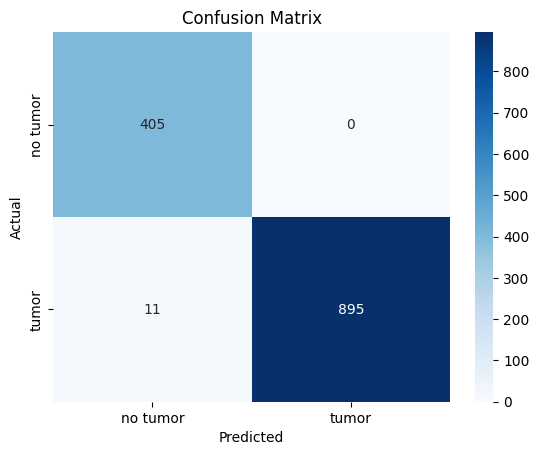

In [17]:
evaluate_model(model, test_loader, device)

In [18]:
torch.save(model.state_dict(), 'resnet18_brain_tumor_classifier.pt')